In [76]:
import pandas as pd
import mysql.connector
import seaborn as sns
import matplotlib.pyplot as plt
from config.db_config import DB_CONFIG
import warnings
warnings.filterwarnings('ignore')

Index(['respondent_id', 'country', 'years_code_pro', 'ed_level', 'dev_type',
       'employment', 'converted_comp_yearly'],
      dtype='object')


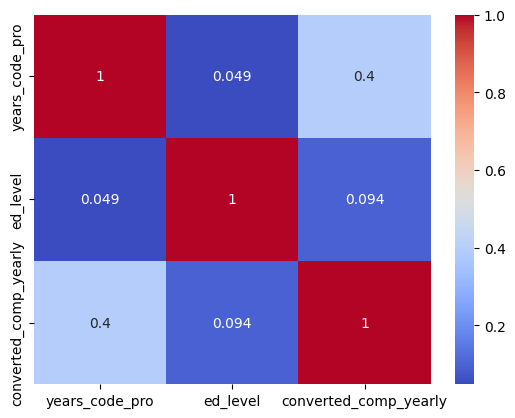

In [77]:
conn = mysql.connector.connect(**DB_CONFIG, database="salary_prediction")
cursor = conn.cursor()

df = pd.read_sql("SELECT * FROM developers", conn)
print(df.columns)

sns.heatmap(df[["years_code_pro", "ed_level", "converted_comp_yearly"]].corr(), annot=True,cmap='coolwarm')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

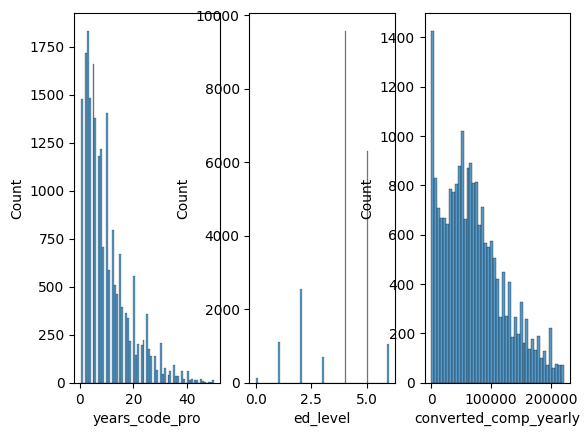

In [78]:
fig, ax = plt.subplots(nrows=1, ncols=3)

sns.histplot(df["years_code_pro"], ax=ax[0])
sns.histplot(df["ed_level"], ax=ax[1])
sns.histplot(df["converted_comp_yearly"], ax=ax[2])
plt.show

Top 5 countries account for 43.657500350156404%
Top 10 countries account for 59.447219758158646%
Top 15 countries account for 70.15266819179233%
Top 20 countries account for 75.93725197254774%
Top 25 countries account for 80.25584761193333%
Top 30 countries account for 83.9348242214856%
Top 35 countries account for 86.89948176852327%
Top 40 countries account for 89.28054531023857%
Top 45 countries account for 91.26009617629208%


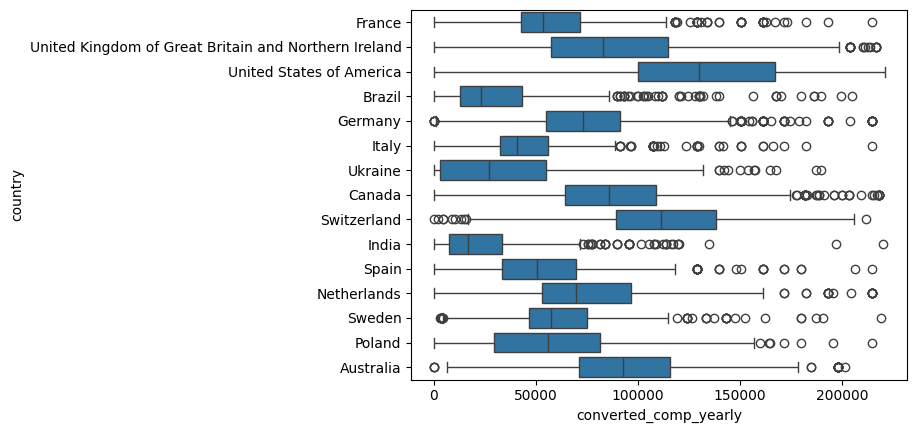

In [79]:
for i in range(5, int(df["country"].count()), 5):
    percent = (df["country"].value_counts().head(i).sum() / df.count())*100
    v = percent["country"]
    print(f"Top {i} countries account for {v}%")
    if v >= 90:
        break
df_top15_countries = df["country"].value_counts().head(15)
# print(df_top15_countries)

top15 = df_top15_countries.index
df_filtered = df[df["country"].isin(top15)]
sns.boxplot(x="converted_comp_yearly", y="country", data=df_filtered)
plt.show()



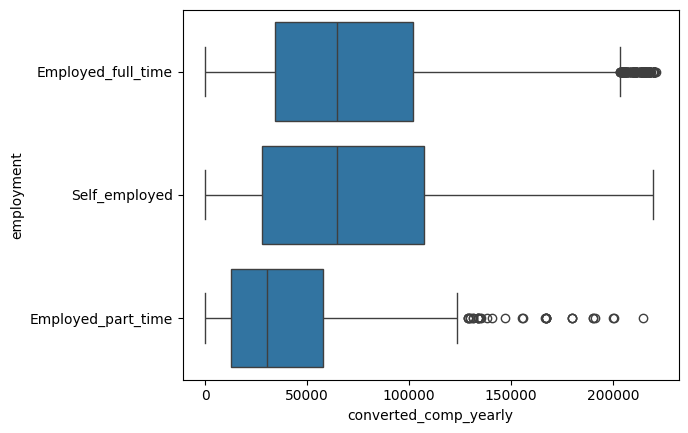

In [80]:
sns.boxplot(x="converted_comp_yearly", y="employment", data=df[["converted_comp_yearly", "employment"]])
plt.show()

Top 5 dev_type account for 72.82319436014754%
Top 10 dev_type account for 84.97128717493814%
Top 15 dev_type account for 91.89037770204025%


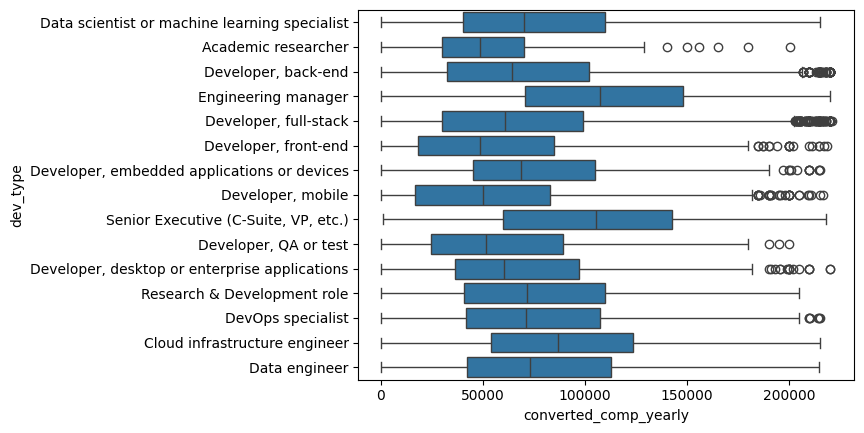

In [81]:
for i in range(5, int(df["dev_type"].count()), 5):
    percent = (df["dev_type"].value_counts().head(i).sum() / df.count())*100
    v = percent["dev_type"]
    print(f"Top {i} dev_type account for {v}%")
    if v >= 90:
        break
df_top15_dev_type = df["dev_type"].value_counts().head(15)
# print(df_top15_countries)

top15 = df_top15_dev_type.index
df_filtered_dev_type = df[df["dev_type"].isin(top15)]
sns.boxplot(x="converted_comp_yearly", y="dev_type", data=df_filtered_dev_type)
plt.show()

Index(['respondent_id', 'converted_comp_yearly', 'language_name'], dtype='object')


<Axes: xlabel='converted_comp_yearly', ylabel='language_name'>

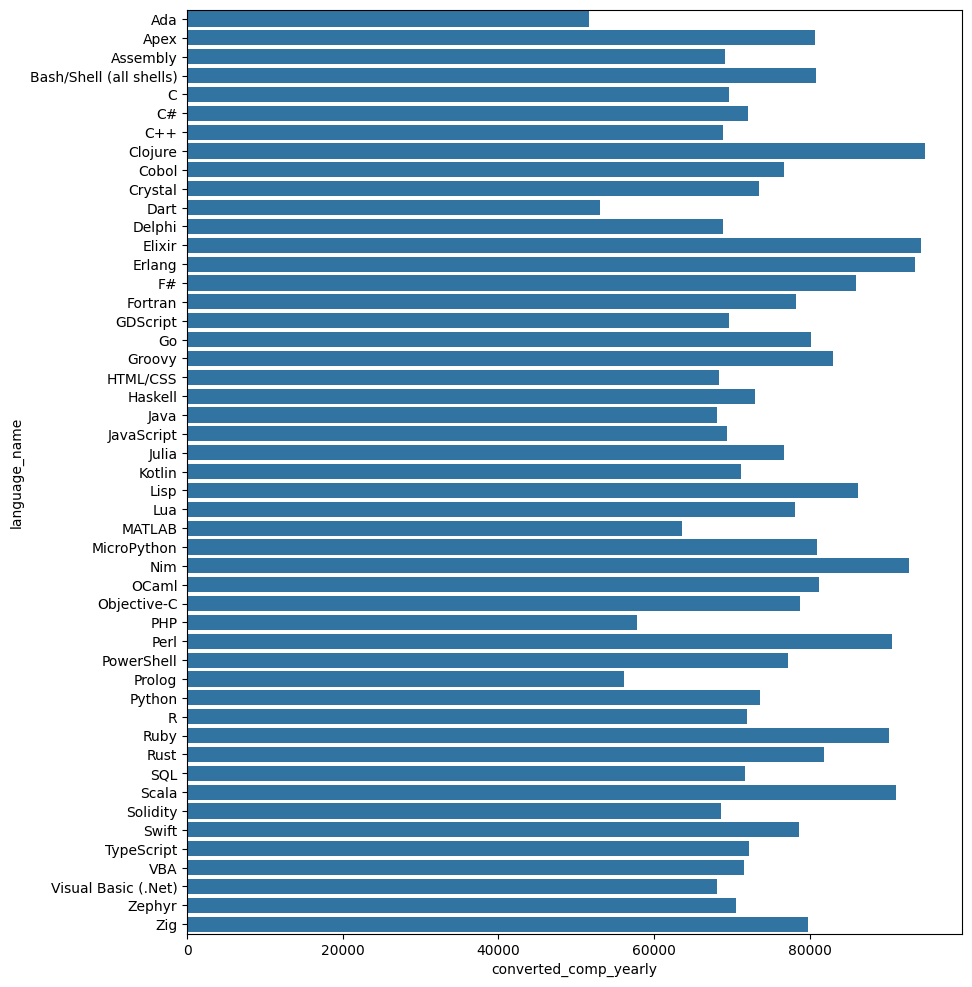

In [84]:
conn = mysql.connector.connect(**DB_CONFIG, database="salary_prediction")
cursor = conn.cursor()
languages_sql = """
SELECT d.respondent_id, d.converted_comp_yearly, l.language_name
FROM developers d 
    INNER JOIN developer_languages dl ON d.respondent_id = dl.respondent_id 
    INNER JOIN languages l ON l.language_id = dl.language_id
ORDER BY d.respondent_id;
"""
df_language = pd.read_sql(languages_sql, conn)
print(df_language.columns)
df_language.head()
df_language_avg = df_language.groupby("language_name")["converted_comp_yearly"].mean().reset_index()
plt.figure(figsize=(10, 12))
sns.barplot(x="converted_comp_yearly", y="language_name", data=df_language_avg)
